# SI figure: grid of line-cut SdH FFT spectra

Ported from `linecut_fft_grid.py` in the `rmg19_quantumoscillations` repo.
This is the **as-generated** figure. The version in the paper (`linecut_fft_grid_edited.pdf`) additionally carries density and contact-pair
labels added by hand in Inkscape, which this notebook does not reproduce.

Grid of line-cut SdH FFT spectra: one ROW per density (line cut), one COLUMN
per contact. Each panel is the standalone FFT-row plot from the fft_redux
diagnostic cells, using the poly5 + gentle-Butterworth composite detrend.

Mirrors the joy-plot recipe (cell 49 of fft_redux.ipynb) but draws each ridge
as its own panel with peak markers + annotations and the per-density 3-cycle
resolution floor shaded, so peaks can be read off quantitatively.

Run from the repo root:
    python linecut_fft_grid.py

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
# ---- Plot styling ---------------------------------------------------------
scale = 0.56
plt.rcParams.update({
    # Font and font sizes
    'font.family': 'sans-serif',
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'font.size': 9,
    'legend.title_fontsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,

    # Ticks
    'xtick.direction': 'in',
    'xtick.top': 'True',
    'ytick.direction': 'in',
    'ytick.right': 'True',

    'xtick.major.size': 5 * scale,
    'xtick.major.width': 1.5 * scale,
    'xtick.minor.size': 2.5 * scale,
    'xtick.minor.width': 1.5 * scale,

    'ytick.major.size': 5 * scale,
    'ytick.major.width': 1.5 * scale,
    'ytick.minor.size': 2.5 * scale,
    'ytick.minor.width': 1.5 * scale,

    # Linewidths
    'axes.linewidth': 1.5 * scale,
    'lines.linewidth': 2.5 * scale,
})

from sweep import sweep_load as sl
from utils import (interp_rxx, make_vec_fft, detrend_butterworth,
                   calculate_gate_voltages, calculate_n_D)

In [3]:
# ---- Data / sweep config (matches fft_redux globals) ----------------------
file_path  = '../data/raw_sweeps'
ns_exp     = np.linspace(0.5, 0.85, 15)
line_files = list(range(1823, 1839))   # 16 files; zip with 15 ns drops the last
CONTACTS   = (1, 2, 3)

In [4]:
# ---- Calibration round-trip: experimental -> gate V -> default ------------
# The line cuts were taken at (n, D) in the *experimental* gate calibration.
# Round-trip through gate voltages into the *default* calibration so the FFT
# frequency axis is normalized by the same density convention as the heatmap.
# Without this, the single-tone QM lands at n_SdH/n ~ 0.93 instead of 1.
rmg19  = json.load(open('../rmg19.json'))
Ds_exp = np.ones_like(ns_exp)
_Vtg, _Vbg = calculate_gate_voltages(ns_exp, Ds_exp,
                                     dtg=rmg19['experimental']['dtg'],
                                     dbg=rmg19['experimental']['dbg'])
ns_plot, _ = calculate_n_D(_Vtg, _Vbg,
                           dtg=rmg19['default']['dtg'],
                           dbg=rmg19['default']['dbg'])

In [5]:
# ---- Which line cuts to show as rows --------------------------------------
# Focus on the low-density region (multitone / CSC), where the low-frequency
# peaks are the point. Drop the high-density QM cuts (n >= 0.75).
# ns_exp = linspace(0.5, 0.85, 15): idx 0->0.500 ... idx 8->0.700, step 0.025.
ROW_IDX = list(range(0, 9))   # n = 0.500 ... 0.700

wrote linecut_fft_grid.pdf


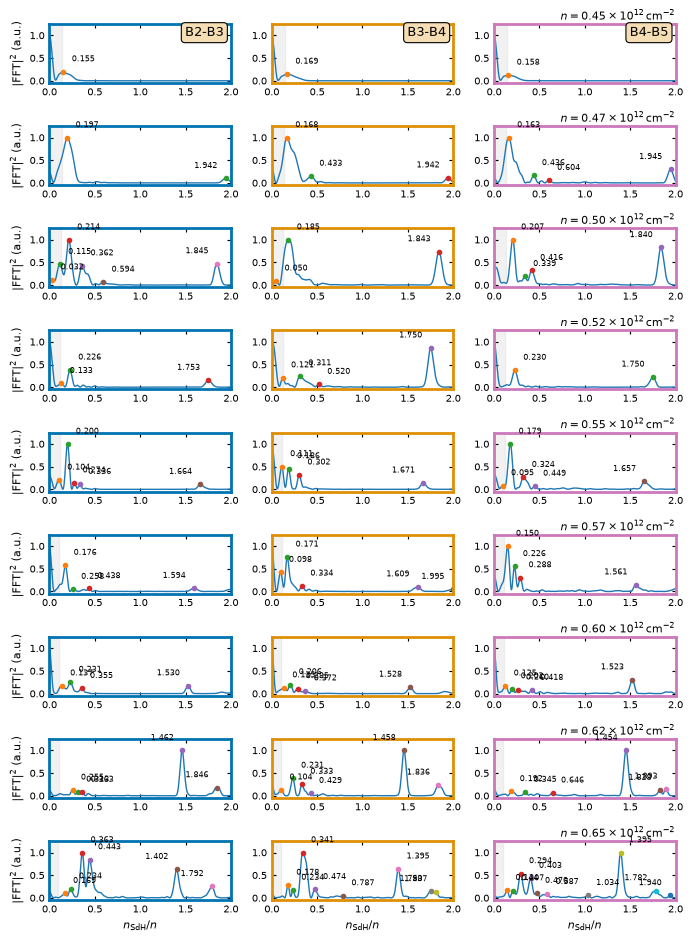

In [6]:
# ---- Detrend / FFT parameters --------------------------------------------
# Butterworth high-pass with a DENSITY-SCALED cutoff (cutoff = n * CUTOFF_OVER_N),
# applied per-row so the high-pass sits at a fixed fraction of the plotted
# n_SdH/n axis. n is the round-tripped (default-calibration) density, i.e. the
# same density used to normalize the frequency axis. (e.g. n=0.65 -> cutoff=5.2.)
filter_lims     = (0.7, 3.5)   # B-field window (T)
BLO, BHI        = filter_lims
NX              = 1000
PADDING         = 8
CUTOFF_OVER_N   = 8         # density-scaled Butterworth cutoff = n * this (cyc/T^-1)
ORDER           = 2

FFT_XLIM        = (0.0, 2.0)
PEAK_PROM_FRAC  = 0.02     # find_peaks prominence as fraction of max
PEAK_HEIGHT_FRAC = 0.05    # find_peaks height as fraction of max

# Per-contact styling (column order matches CONTACTS = (1, 2, 3))
contact_labels = ["B2-B3", "B3-B4", "B4-B5"]
contact_colors = ["#0173B2", "#DE8F05", "#CC78BC"]

# 3-cycle resolvable-frequency floor (per density, in f/(nh/e) units)
_PHI0  = 6.626e-34 / 1.6002e-19
_L_invB = 1.0 / BLO - 1.0 / BHI
_x_thresh = FFT_XLIM[0] + 0.7 * (FFT_XLIM[1] - FFT_XLIM[0])


def spectrum(file, n, contact):
    """Density-scaled Butterworth high-pass -> normalized 1/B power spectrum."""
    d = sl.pload(file_path, file)
    B = np.asarray(d['xs'])
    desc = B[0] > B[-1]
    I = np.asarray(d['sr830_4_X'])
    V = np.asarray(d[f'sr830_{contact}_X'])
    if desc:
        B, I, V = B[::-1], I[::-1], V[::-1]
    lo = np.abs(B - BLO).argmin()
    hi = np.abs(B - BHI).argmin()
    R = V / I
    invB_u, R_u = interp_rxx(B[lo:hi], R[lo:hi], nx=NX)
    # Density-scaled high-pass cutoff (cyc/T^-1), order ORDER. n is the
    # round-tripped default-calibration density used for the frequency axis.
    R_hp, _ = detrend_butterworth(invB_u, R_u,
                                  cutoff=n * CUTOFF_OVER_N, order=ORDER)
    fft_full, freq_full = make_vec_fft(invB_u, R_hp, n,
                                       padding=PADDING, normalize=True)
    npos = len(freq_full) // 2
    return freq_full[:npos], fft_full[:npos]


n_rows = len(ROW_IDX)
n_cols = len(CONTACTS)
# Full-page portrait (US-letter text block ~ 7.0 x 9.5 in)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(7.0, 9.5),
                         squeeze=False, sharex=True)

for r, idx in enumerate(ROW_IDX):
    n    = ns_plot[idx]          # default-calibration density (round-tripped)
    file = line_files[idx]
    f_floor = 3.0 / _L_invB / (_PHI0 * n * 1e16)   # per-density 3-cycle floor
    for c, contact in enumerate(CONTACTS):
        ax = axes[r, c]
        freq, fft = spectrum(file, n, contact)
        peaks, _ = find_peaks(fft,
                              prominence=PEAK_PROM_FRAC * np.nanmax(fft),
                              height=PEAK_HEIGHT_FRAC * np.nanmax(fft))
        ax.plot(freq, fft, linewidth=1)
        for p in peaks:
            f0, y0 = freq[p], fft[p]
            if f0 < FFT_XLIM[0] or f0 > FFT_XLIM[1]:
                continue
            ax.plot(f0, y0, marker='o', markersize=3)
            if f0 > _x_thresh:
                xytext, ha = (-6, 6), 'right'
            else:
                xytext, ha = (6, 6), 'left'
            ax.annotate(f'{f0:.3f}', xy=(f0, y0), xytext=xytext,
                        textcoords='offset points', fontsize=6, ha=ha, va='bottom')
        ax.axvspan(0, f_floor, color='lightgray', alpha=0.3, zorder=0)
        ax.set_xlim(*FFT_XLIM)
        ax.set_ylim(top=1.25)   # headroom above the normalized peak for labels
        ax.tick_params(labelbottom=True)   # show tick numbers on every row

        # Colored spines on every row
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor(contact_colors[c])
        # Boxed contact label only in the top row
        if r == 0:
            ax.text(0.96, 0.96, contact_labels[c], transform=ax.transAxes,
                    ha='right', va='top', fontsize=9, color='k',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                              edgecolor='k', linewidth=0.8, alpha=1))

        if r == n_rows - 1:
            ax.set_xlabel(r'$n_{\mathrm{SdH}}/n$')
        if c == 0:
            ax.set_ylabel(r'$|\mathrm{FFT}|^2$ (a.u.)', fontsize=8)
        # Density label horizontally above the frame, top-right of right column
        if c == n_cols - 1:
            ax.text(1.0, 1.02,
                    rf'$n={n:.2f}\times10^{{12}}\,\mathrm{{cm}}^{{-2}}$',
                    transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=8, color='k')

fig.tight_layout()
fig.savefig('linecut_fft_grid.pdf', bbox_inches='tight')
print('wrote linecut_fft_grid.pdf')
plt.show()